<a href="https://colab.research.google.com/github/abcdon21/dataCleaningPD/blob/main/Polynomial_Regression_(Multiple_features)_Fish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#from google.colab import files
#uploaded= files.upload()

Saving Fish.csv to Fish.csv


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df= pd.read_csv('Fish.csv')
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [5]:
df.info() #no need for cleaning

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [6]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
154,False
155,False
156,False
157,False


In [7]:
df=df.drop_duplicates()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


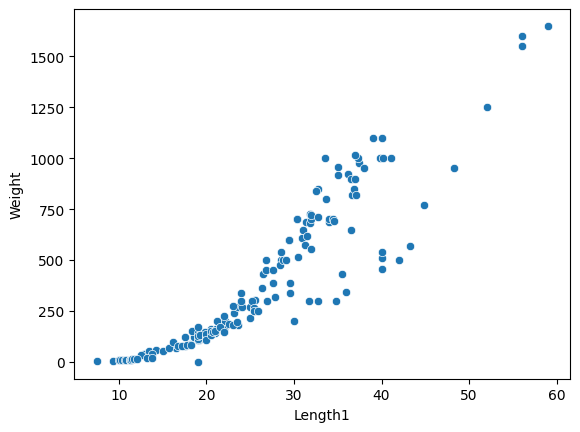

In [12]:
sns.scatterplot(x='Length1',y='Weight',data=df) #seaborn function
plt.show()


In [14]:
X=df.drop(['Weight','Species'],axis=1)
X.head()

,Length1,Length2,Length3,Height,Width
0,23.2,25.4,30.0,11.5200,4.0200
1,24.0,26.3,31.2,12.4800,4.3056
2,23.9,26.5,31.1,12.3778,4.6961
3,26.3,29.0,33.5,12.7300,4.4555
4,26.5,29.0,34.0,12.4440,5.1340


In [15]:
y= df['Weight']
y.head()

,Weight
0,242.0
1,290.0
2,340.0
3,363.0
4,430.0


In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)


In [18]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [19]:
y_pred= model.predict(X_test)


In [24]:
model.intercept_ #slope calucaltion

np.float64(-515.305651338433)

In [21]:
model.coef_

array([ 43.5352649 ,   7.82179624, -25.25670105,  23.2289123 ,
        27.06649294])

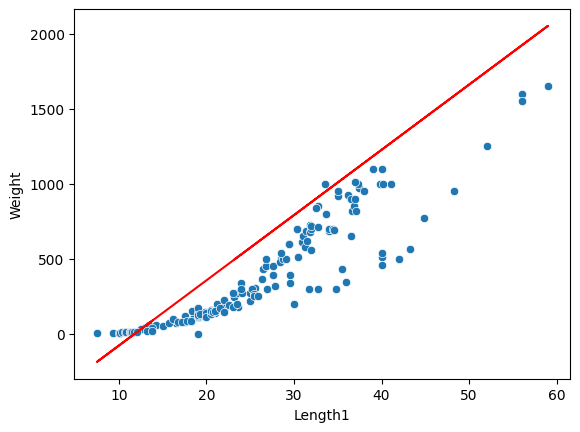

In [26]:
xaxis=df['Length1']
yaxis=43.53*xaxis-515
sns.scatterplot(x='Length1',y='Weight',data=df)
plt.plot(xaxis,yaxis,color='red')
plt.show()


In [28]:

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


# POLYNOMIAL TRANFORMATION - making data points linear

In [42]:
r2_list=[]
for i in range(0,11):

    from sklearn.metrics import r2_score#r2 score should be between 0 to 1 and it decides how good model will perform

    pf= PolynomialFeatures(degree=i) #degree decides how much transformation will take place
    X_train_poly=pf.fit_transform(X_train)#coverting into 3d

    X_test_poly=pf.fit_transform(X_test)

    lr= LinearRegression()
    lr.fit(X_train_poly,y_train)#xtrainpoly is linear data now

    y_pred= lr.predict(X_test_poly)


    r2s=r2_score(y_test,y_pred)
    r2_list.append(r2s)
    print(f'Degree:{i}, R2 Score:{r2s}')

Degree:0, R2 Score:-0.023082268458468613
Degree:1, R2 Score:0.8821430593048696
Degree:2, R2 Score:0.9672675055786767
Degree:3, R2 Score:0.9609431981617572
Degree:4, R2 Score:-422.86498116892227
Degree:5, R2 Score:-428.91736199843837
Degree:6, R2 Score:-1306.7900206333277
Degree:7, R2 Score:-3862.1649282700373
Degree:8, R2 Score:-7218.979550711392
Degree:9, R2 Score:-158961.2649634807
Degree:10, R2 Score:-202694.37925916773


In [44]:
print(r2_list)
#maximum r2 score
max(r2_list)
#jis bhi index pe max r2 score hi wo best degree hogi

[-0.023082268458468613, 0.8821430593048696, 0.9672675055786767, 0.9609431981617572, -422.86498116892227, -428.91736199843837, -1306.7900206333277, -3862.1649282700373, -7218.979550711392, -158961.2649634807, -202694.37925916773]


0.9672675055786767

In [31]:
print(X_train_poly)

[[  1.          15.          16.2        ...  21.09013776  12.08535984
    6.92531856]
 [  1.          43.2         46.         ...  60.715264    37.94704
   23.7169    ]
 [  1.          23.9         26.5        ... 153.20993284  58.12738658
   22.05335521]
 ...
 [  1.          29.4         32.         ... 223.63407936  77.32621152
   26.73717264]
 [  1.          20.5         22.5        ...  46.131264    24.614208
   13.133376  ]
 [  1.          25.2         27.3        ...  69.272329    42.7577479
   26.39185129]]


In [32]:
X_train.head()

,Length1,Length2,Length3,Height,Width
75,15.0,16.2,17.2,4.5924,2.6316
138,43.2,46.0,48.7,7.7920,4.8700
2,23.9,26.5,31.1,12.3778,4.6961
86,20.0,22.0,23.5,6.1100,3.4075
45,20.5,22.5,25.3,7.0334,3.8203
